In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20, zoom_range=0.2)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input

# Load EfficientNetB0 base model (no top layer)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add GlobalAveragePooling layer to flatten output
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_model = Model(inputs=base_model.input, outputs=x)


In [ ]:
train_generator.reset()
val_generator.reset()
test_generator.reset()

# Extract and Save Train
X_train, y_train = extract_features_with_progress(train_generator, "train", feature_model, batch_size)
save_features(X_train, y_train, "train")

# Extract and Save Validation
X_val, y_val = extract_features_with_progress(val_generator, "val", feature_model, batch_size)
save_features(X_val, y_val, "val")

# Extract and Save Test
X_test, y_test = extract_features_with_progress(test_generator, "test", feature_model, batch_size)
save_features(X_test, y_test, "test")


In [ ]:
import numpy as np

X_train = np.load("/content/drive/MyDrive/X_train.npy")

y_train = np.load("/content/drive/MyDrive/y_train.npy")

X_val = np.load("/content/drive/MyDrive/X_val.npy")
y_val = np.load("/content/drive/MyDrive/y_val.npy")

X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

In [ ]:
print(X_train.shape)
print(X_train[0])   # features of the first image
print(y_train[0])   # label (0 or 1)


(28000, 1280)
[-0.06976742 -0.09847549 -0.13400078 ... -0.19394957 -0.04931246
  0.05364386]
[1.]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("📦 Feature shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\n🏷️ Label shapes:")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

# Optionally preview some values
print("\n🔍 Sample y_train values:", y_train[:10])

📦 Feature shapes:
X_train: (28000, 1280)
X_val: (6000, 1280)
X_test: (6000, 1280)

🏷️ Label shapes:
y_train: (28000, 1)
y_val: (6000, 1)
y_test: (6000, 1)

🔍 Sample y_train values: [[1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time

# Base model
base_model = DecisionTreeClassifier(max_depth=3)

# Enable warm_start to fit one estimator at a time
ada_model = AdaBoostClassifier(estimator=base_model, n_estimators=20, learning_rate=0.5)

# Total number of estimators to add
total_estimators = 100

print("⏳ Training AdaBoost model with progress bar...")
start_time = time.time()

# Incrementally train with progress bar
for i in tqdm(range(1, total_estimators + 1), desc="Training Progress"):
    ada_model.n_estimators = i
    ada_model.fit(X_train_selected, y_train.ravel())  # ravel to fix shape warning

end_time = time.time()
print(f"✅ Training completed in {end_time - start_time:.2f} seconds.")


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Feature Selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=100)  # You can adjust k as needed
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Print the shapes after feature selection
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_val_selected shape: {X_val_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


X_train_selected shape: (28000, 100)
X_val_selected shape: (6000, 100)
X_test_selected shape: (6000, 100)


In [ ]:
import joblib

# Path to the saved model in Google Drive
model_load_path = "/content/drive/MyDrive/deepfake_adaboost_model.joblib"

# Load the model
ada_model = joblib.load(model_load_path)

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = ada_model.predict(X_train_selected)
train_acc = accuracy_score(y_train, y_train_pred)

# Predict on test data
y_test_pred = ada_model.predict(X_test_selected)
test_acc = accuracy_score(y_test, y_test_pred)

# Predict on validation data
y_val_pred = ada_model.predict(X_val_selected)
val_acc = accuracy_score(y_val, y_val_pred)

print("\n📊 Model Accuracy Results:")
print(f"✅ Training Accuracy   : {train_acc * 100:.2f}%")
print(f"✅ Testing Accuracy    : {test_acc * 100:.2f}%")
print(f"✅ Validation Accuracy : {val_acc * 100:.2f}%")



📊 Model Accuracy Results:
✅ Training Accuracy   : 68.27%
✅ Testing Accuracy    : 61.73%
✅ Validation Accuracy : 64.17%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 📥 Load features and labels
X_train = np.load("/content/drive/MyDrive/X_train.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
X_val = np.load("/content/drive/MyDrive/X_val.npy")
y_val = np.load("/content/drive/MyDrive/y_val.npy")
X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

# ✅ One-hot encode labels (binary classification assumed)
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# ✅ Normalize input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ✅ Build improved model
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(2, activation='softmax')  # 2 classes
])

# ✅ Compile model with alternative optimizer
model.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ✅ Use EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# 🔁 Train model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stop],
                    verbose=1)

# 🧪 Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

# 📊 Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 🔍 Predict and check prediction accuracy
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
final_acc = accuracy_score(y_test_labels, y_pred_labels)
print(f"🔍 Prediction Accuracy: {final_acc * 100:.2f}%")

# 💾 Save model to Google Drive
model.save('/content/drive/MyDrive/improved_model.h5')
print("✅ Model saved to Drive as 'improved_model.h5'")


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load saved model
model = load_model('/content/drive/MyDrive/improved_model.h5')

# Load the data
X_train = np.load("/content/drive/MyDrive/X_train.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Evaluate on training data
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

# ✅ Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# ✅ Predict and check prediction accuracy manually
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

pred_accuracy = accuracy_score(y_test_labels, y_pred_labels)
print(f"Prediction Accuracy (manual): {pred_accuracy * 100:.2f}%")


Training Accuracy: 75.50%
Test Accuracy: 69.33%
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediction Accuracy (manual): 69.33%


Saving real_1.jpg to real_1.jpg
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


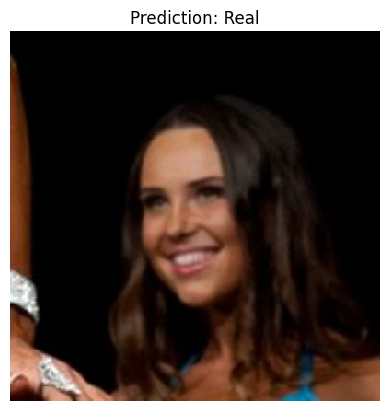

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
import os

from google.colab import files
uploaded = files.upload()  # 📂 Upload the image file from your local system

# Load your trained model
model = load_model('/content/drive/MyDrive/improved_model.h5')

# Class names
class_names = ['Fake', 'Real']  # adjust this if your classes are different

# Process the uploaded image
for filename in uploaded.keys():
    # Load image and resize (EfficientNetB0 expects 224x224)
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Preprocess using EfficientNetB0 preprocessing
    img_preprocessed = preprocess_input(img_array_expanded)

    # Extract features using EfficientNetB0
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, pooling='avg', input_shape=(224, 224, 3))
    features = base_model.predict(img_preprocessed)

    # Predict using your classifier model
    prediction = model.predict(features)
    predicted_label = class_names[np.argmax(prediction)]

    # Show the result
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label}")
    plt.axis('off')
    plt.show()


✅ Training Accuracy: 75.50%
✅ Test Accuracy: 69.33%


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✅ Manual Accuracy: 69.33%


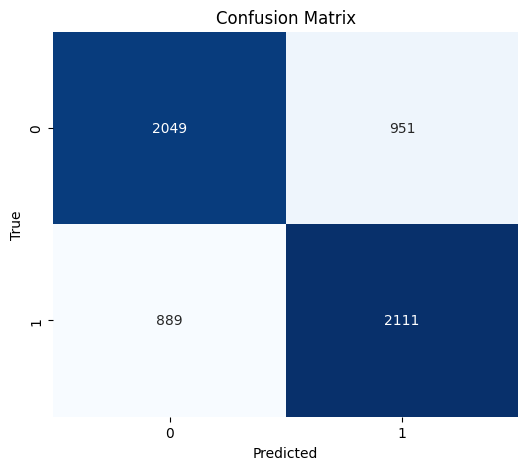

📋 Classification Report:
               precision    recall  f1-score   support

     Class 0       0.70      0.68      0.69      3000
     Class 1       0.69      0.70      0.70      3000

    accuracy                           0.69      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.69      0.69      0.69      6000



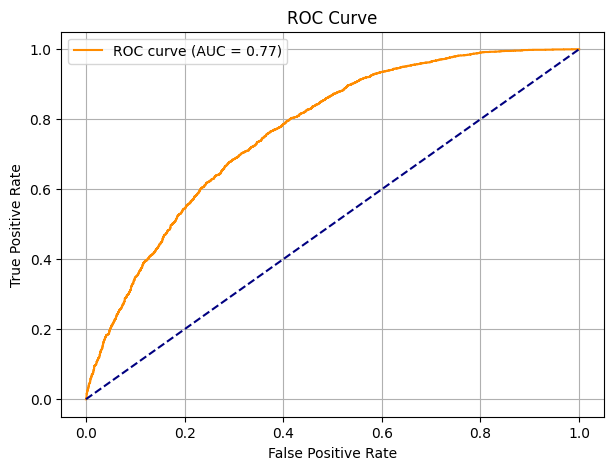

📊 Confidence Interval (95%) for Accuracy: (68.17%, 70.50%)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
model = load_model('/content/drive/MyDrive/improved_model.h5')

# Load extracted features and labels
X_train = np.load("/content/drive/MyDrive/X_train.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Evaluate on train set
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"✅ Training Accuracy: {train_acc * 100:.2f}%")

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

# Predict
y_pred_proba = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_proba, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Accuracy (manual)
acc_manual = accuracy_score(y_true_labels, y_pred_labels)
print(f"✅ Manual Accuracy: {acc_manual * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true_labels, y_pred_labels, target_names=["Class 0", "Class 1"])
print("📋 Classification Report:\n", report)

# ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_true_labels, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Confidence Interval for Accuracy
n = len(y_true_labels)
conf_level = 0.95
z = stats.norm.ppf(1 - (1 - conf_level) / 2)
se = np.sqrt((acc_manual * (1 - acc_manual)) / n)
margin = z * se
ci_lower = acc_manual - margin
ci_upper = acc_manual + margin

print(f"📊 Confidence Interval (95%) for Accuracy: ({ci_lower * 100:.2f}%, {ci_upper * 100:.2f}%)")


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Load data
X_train = np.load("/content/drive/MyDrive/X_train.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
X_val = np.load("/content/drive/MyDrive/X_val.npy")
y_val = np.load("/content/drive/MyDrive/y_val.npy")
X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

y_train = y_train.ravel()
y_val = y_val.ravel()
y_test = y_test.ravel()

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Combine train and val for later evaluation
X_train_full = np.concatenate((X_train, X_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

# Class weight
counter = Counter(y_train_full.tolist())
scale_pos_weight = counter[0] / counter[1]
print("Class Balance:", counter)
print("Scale Pos Weight:", scale_pos_weight)

# DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Parameters (tuned)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 8,
    'learning_rate': 0.02,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 1.5,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist'
}

# Training with early stopping
evals = [(dtrain, 'train'), (dval, 'val')]
evals_result = {}

print("⏳ Training XGBoost with early stopping...")
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=25,
    evals_result=evals_result,
    verbose_eval=10
)

# Predict
train_preds = (model.predict(xgb.DMatrix(X_train_full)) > 0.5).astype(int)
test_preds = (model.predict(dtest) > 0.5).astype(int)

# Accuracy
train_acc = accuracy_score(y_train_full, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"\n✅ Final Train Accuracy: {train_acc:.4f}")
print(f"✅ Final Test Accuracy: {test_acc:.4f}")


Class Balance: Counter({1.0: 17000, 0.0: 17000})
Scale Pos Weight: 1.0
⏳ Training XGBoost with early stopping...
[0]	train-logloss:0.68870	val-logloss:0.69096
[10]	train-logloss:0.65059	val-logloss:0.67324
[20]	train-logloss:0.61906	val-logloss:0.66000
[30]	train-logloss:0.59239	val-logloss:0.64954
[40]	train-logloss:0.57038	val-logloss:0.64230
[50]	train-logloss:0.55033	val-logloss:0.63596
[60]	train-logloss:0.53278	val-logloss:0.63069
[70]	train-logloss:0.51724	val-logloss:0.62681
[80]	train-logloss:0.50208	val-logloss:0.62346
[90]	train-logloss:0.48799	val-logloss:0.62072
[100]	train-logloss:0.47582	val-logloss:0.61827
[110]	train-logloss:0.46380	val-logloss:0.61593
[120]	train-logloss:0.45183	val-logloss:0.61389
[130]	train-logloss:0.44086	val-logloss:0.61203
[140]	train-logloss:0.43062	val-logloss:0.61069
[150]	train-logloss:0.42132	val-logloss:0.60919
[160]	train-logloss:0.41325	val-logloss:0.60767
[170]	train-logloss:0.40423	val-logloss:0.60708
[180]	train-logloss:0.39568	val-lo

In [ ]:
# Save path in Google Drive
model_save_path = "/content/drive/MyDrive/xgboost_deepfake_model123.json"

# Save the trained model
model.save_model(model_save_path)

print(f"✅ Model saved successfully at: {model_save_path}")


✅ Model saved successfully at: /content/drive/MyDrive/xgboost_deepfake_model123.json


In [ ]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif


In [ ]:
X_train = np.load("/content/drive/MyDrive/X_train.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")

X_val = np.load("/content/drive/MyDrive/X_val.npy")
y_val = np.load("/content/drive/MyDrive/y_val.npy")

X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

# Flatten labels if needed
y_train = y_train.ravel()
y_val = y_val.ravel()
y_test = y_test.ravel()


In [ ]:
# Prepare LightGBM dataset
train_data = lgb.Dataset(X_train_selected, label=y_train.ravel())
val_data = lgb.Dataset(X_val_selected, label=y_val.ravel(), reference=train_data)


In [ ]:
# LightGBM parameters
params = {
    'objective': 'binary',          # Binary classification
    'metric': 'binary_error',       # We want to track binary error (accuracy)
    'learning_rate': 0.05,         # Learning rate
    'num_leaves': 31,              # Max number of leaves in trees
    'verbose': -1                   # To suppress verbose output
}


In [ ]:
import lightgbm as lgb
import time
from sklearn.metrics import accuracy_score
import numpy as np

# Prepare the LightGBM datasets
train_data = lgb.Dataset(X_train_selected, label=y_train)
val_data = lgb.Dataset(X_val_selected, label=y_val, reference=train_data)

# LightGBM parameters
params = {
    'objective': 'binary',          # Binary classification problem
    'metric': 'binary_error',       # Metric to track: binary classification error
    'learning_rate': 0.05,          # Learning rate
    'num_leaves': 31,               # Number of leaves in each tree
    'verbose': -1                   # Suppress verbose output
}

print("⏳ Training LightGBM model with progress bar...")

start_time = time.time()

# Train the model with early stopping using valid_sets parameter
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=200,            # Max number of boosting rounds
    valid_sets=[val_data],  # Validation datasets
                                # Stop if no improvement in 20 rounds
    callbacks=[lgb.log_evaluation(10)]                # Print info every 20 rounds
)

end_time = time.time()
print(f"✅ Training completed in {end_time - start_time:.2f} seconds.")


⏳ Training LightGBM model with progress bar...
[10]	valid_0's binary_error: 0.379833
[20]	valid_0's binary_error: 0.369167
[30]	valid_0's binary_error: 0.364333
[40]	valid_0's binary_error: 0.3565
[50]	valid_0's binary_error: 0.350667
[60]	valid_0's binary_error: 0.351833
[70]	valid_0's binary_error: 0.350833
[80]	valid_0's binary_error: 0.349333
[90]	valid_0's binary_error: 0.348
[100]	valid_0's binary_error: 0.350167
[110]	valid_0's binary_error: 0.3515
[120]	valid_0's binary_error: 0.351333
[130]	valid_0's binary_error: 0.350333
[140]	valid_0's binary_error: 0.349833
[150]	valid_0's binary_error: 0.3495
[160]	valid_0's binary_error: 0.349667
[170]	valid_0's binary_error: 0.3475
[180]	valid_0's binary_error: 0.345667
[190]	valid_0's binary_error: 0.347667
[200]	valid_0's binary_error: 0.346333
✅ Training completed in 8.99 seconds.


In [ ]:
# Predictions on training data
train_preds = lgb_model.predict(X_train_selected, num_iteration=lgb_model.best_iteration)
train_preds = (train_preds > 0.5).astype(int)  # Convert probabilities to class labels
train_acc = accuracy_score(y_train, train_preds)

# Predictions on validation data
val_preds = lgb_model.predict(X_val_selected, num_iteration=lgb_model.best_iteration)
val_preds = (val_preds > 0.5).astype(int)  # Convert probabilities to class labels
val_acc = accuracy_score(y_val, val_preds)

# Predictions on test data
test_preds = lgb_model.predict(X_test_selected, num_iteration=lgb_model.best_iteration)
test_preds = (test_preds > 0.5).astype(int)  # Convert probabilities to class labels
test_acc = accuracy_score(y_test, test_preds)

# Output the accuracy results
print(f"✅ Training Accuracy: {train_acc * 100:.2f}%")
print(f"📊 Validation Accuracy: {val_acc * 100:.2f}%")
print(f"🧪 Test Accuracy: {test_acc * 100:.2f}%")


✅ Training Accuracy: 78.56%
📊 Validation Accuracy: 65.37%
🧪 Test Accuracy: 63.00%


In [ ]:
# Save path in Google Drive
model_save_path = "/content/drive/MyDrive/lgb_deepfake_model123.json"

# Save the trained model
model.save_model(model_save_path)

print(f"✅ Model saved successfully at: {model_save_path}")


✅ Model saved successfully at: /content/drive/MyDrive/lgb_deepfake_model123.json


In [ ]:
!pip install gradio
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf

# Load your trained model
model_path = '/content/drive/MyDrive/improved_model.h5'
model = load_model(model_path)

# Class names
class_names = ['Fake', 'Real']  # Update this if your class names are different

# Base model for feature extraction
base_model = tf.keras.applications.EfficientNetB0(include_top=False, pooling='avg', input_shape=(224, 224, 3))

def predict_image(img):
    """Process and predict the uploaded image."""
    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Preprocess the image
    img_preprocessed = preprocess_input(img_array_expanded)

    # Extract features
    features = base_model.predict(img_preprocessed)

    # Predict using your classifier model
    prediction = model.predict(features)
    predicted_label = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100  # Confidence percentage
    return f"Prediction: {predicted_label} ({confidence:.2f}% confidence)"

# Create Gradio interface
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),  # Accepts image input
    outputs="text",  # Displays text output
    title="Image Classification",
    description="Upload an image to classify it as Fake or Real."
)

# Launch the interface
interface.launch(debug=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.3 MB/s eta 0:00:00


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://52545c5fa02ac4c55f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
